# Telecom Customer Churn Prediction: A Hypothesis-Driven Analysis

## Project Overview
The telecommunications sector in India is highly competitive, with customers frequently switching between providers (a process known as "churn"). Understanding the factors that influence customer retention is crucial for telecom companies to enhance service quality, optimize marketing spend, and maximize profitability.

As the Lead Data Scientist on this project, the objective is to explore customer behavior and demographics to predict churn. We utilize two comprehensive datasets covering four major telecom partners: Airtel, Reliance Jio, Vodafone, and BSNL.

### Datasets
1. **`telecom_demographics.csv`**: Contains customer demographic information (Age, Gender, Location, Salary, Dependents, etc.).
2. **`telecom_usage.csv`**: Contains customer usage patterns (Calls made, SMS sent, Data used, and the target variable: `churn`).

---
## 1. Environment Setup & Data Loading
First, we'll import the necessary libraries for data manipulation, machine learning, and visualization.

In [1]:
# Data Manipulation & Visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning & Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

%matplotlib inline

# Setting random seed for reproducibility
SEED = 42

We merge the demographics and usage datasets on their common identifier, `customer_id`, to create a unified view of each customer.

In [2]:
# Import and merge datasets
t_demo = pd.read_csv("telecom_demographics.csv")
t_usage = pd.read_csv("telecom_usage.csv")

churn_df = t_demo.merge(t_usage, on='customer_id')

# Display dataset structure
print(f"Dataset shape: {churn_df.shape}\n")
display(churn_df.head())

Dataset shape: (6500, 14)



,customer_id,telecom_partner,gender,age,state,city,pincode,registration_event,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,15169,Airtel,F,26,Himachal Pradesh,Delhi,667173,2020-03-16,4,85979,75,21,4532,1
1,149207,Airtel,F,74,Uttarakhand,Hyderabad,313997,2022-01-16,0,69445,35,38,723,1
2,148119,Airtel,F,54,Jharkhand,Chennai,549925,2022-01-11,2,75949,70,47,4688,1
3,187288,Reliance Jio,M,29,Bihar,Hyderabad,230636,2022-07-26,3,34272,95,32,10241,1
4,14016,Vodafone,M,45,Nagaland,Bangalore,188036,2020-03-11,4,34157,66,23,5246,1


## 2. Initial Data Exploration
Before building models, it is essential to understand the baseline churn rate. This gives us the "prior probability" of a customer leaving and highlights any class imbalance.

In [3]:
# Calculate the global churn rate
churn_rate = churn_df['churn'].value_counts(normalize=True)[1]
print(f'Customer Churn Rate: {churn_rate:.2%}')

Customer Churn Rate: 20.05%


A **~20% churn rate** indicates a mild class imbalance. While not extreme, it means that evaluating our models on accuracy alone will be misleading (a naive model predicting "No Churn" for everyone would be 80% accurate but useless for our business goals).

## 3. Data Preprocessing
Machine learning models require numerical inputs. We will:
1. **One-Hot Encode** categorical variables (e.g., gender, telecom partner, state).
2. **Standardize** continuous numerical variables (e.g., age, data used, salary) so they are on the same scale, which is particularly important for models like Logistic Regression.

In [4]:
# Separate categorical and numeric variables
cat_cols = [
    'telecom_partner',
    'gender',
    'state',
    'city',
    'registration_event'
]

# Pincode is excluded as it is a high-cardinality identifier rather than a continuous numeric feature
num_cols = [
    'age',
    'num_dependents',
    'estimated_salary',
    'calls_made',
    'sms_sent',
    'data_used'
]

# 1. One-Hot Encoding for categorical variables
categorical_encoded = pd.get_dummies(churn_df[cat_cols], drop_first=True)

# 2. Feature Scaling for numeric variables
scaler = StandardScaler()
num_scaled = scaler.fit_transform(churn_df[num_cols])
df_num_scaled = pd.DataFrame(num_scaled, columns=num_cols, index=churn_df.index)

# Combine processed features
features_scaled = pd.concat([df_num_scaled, categorical_encoded], axis=1)
target = churn_df['churn']

print(f"Processed feature matrix shape: {features_scaled.shape[0]} rows and {features_scaled.shape[1]} columns.")

Processed feature matrix shape: 6500 rows and 1257 columns.


### Train-Test Split
We split the data into 80% training and 20% testing sets. We use `stratify=target` to ensure the 20% churn rate is proportionally maintained in both subsets.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, 
    target,
    test_size=0.20,
    random_state=SEED,
    stratify=target
)

## 4. Baseline Modeling
We will establish baseline performance using two standard classification algorithms: **Logistic Regression** and **Random Forest Classifier**.

In [6]:
print("--- Logistic Regression Baseline ---")
logreg = LogisticRegression(random_state=SEED, max_iter=1000)
logreg.fit(X_train, y_train)

logreg_pred = logreg.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, logreg_pred))
print("\nClassification Report:")
print(classification_report(y_test, logreg_pred, zero_division=0))

--- Logistic Regression Baseline ---
Confusion Matrix:
[[1032    7]
 [ 261    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89      1039
           1       0.00      0.00      0.00       261

    accuracy                           0.79      1300
   macro avg       0.40      0.50      0.44      1300
weighted avg       0.64      0.79      0.71      1300



In [7]:
print("--- Random Forest Baseline ---")
rf = RandomForestClassifier(random_state=SEED)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, zero_division=0))

--- Random Forest Baseline ---
Confusion Matrix:
[[1035    4]
 [ 261    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1039
           1       0.00      0.00      0.00       261

    accuracy                           0.80      1300
   macro avg       0.40      0.50      0.44      1300
weighted avg       0.64      0.80      0.71      1300



### Baseline Analysis
**The Problem:** While both models show ~79-80% overall accuracy, the **recall for the churn class (1) is 0.00**. 

This means the models are essentially acting as "majority class predictors", predicting that *no one* will churn. For a business use case, this is a total failure, as the entire point is to identify customers at risk of leaving.

---
## 5. Hypothesis-Driven Troubleshooting
Why are the models failing to detect churners? Let's investigate via hypothesis testing.

### Hypothesis 1: "The model knows who the churners are, but the default 0.5 probability threshold is hiding them."
By default, `sklearn` predicts class 1 if the predicted probability is > 0.5. If our model is consistently predicting a 0.3 or 0.4 probability for actual churners, lowering the threshold might expose them.

In [8]:
# Fetch the probability of churn from the Random Forest model
rf_probs = rf.predict_proba(X_test)[:, 1]

print("Probability Distribution Insights:")
print(f"Max Confidence: {rf_probs.max():.2f}")
print(f"Min Confidence: {rf_probs.min():.2f}")
print(f"Mean Confidence: {rf_probs.mean():.2f}\n")

# Experiment: Lowering the decision threshold to 0.3
rf_pred_03 = (rf_probs >= 0.3).astype(int)

print("Classification Report (Threshold = 0.3):")
print(classification_report(y_test, rf_pred_03))

Probability Distribution Insights:
Max Confidence: 0.59
Min Confidence: 0.02
Mean Confidence: 0.17

Classification Report (Threshold = 0.3):
              precision    recall  f1-score   support

           0       0.79      0.92      0.85      1039
           1       0.13      0.05      0.07       261

    accuracy                           0.74      1300
   macro avg       0.46      0.48      0.46      1300
weighted avg       0.66      0.74      0.69      1300



**Hypothesis 1 Result: Partially True, but Insufficient.**
* Recall increased from 0% → 5%.
* Accuracy dropped from 79% → 74%.

More concerning is that the **maximum predicted probability for ANY customer in the test set is only 0.59**. The model simply lacks confidence in identifying churners. This indicates the issue goes deeper than just the threshold.

### Hypothesis 2: "The model ignores churners because the classes are imbalanced."
Since only 20% of the dataset represents churners, the model might optimize its loss function by favoring the majority class. We can penalize misclassifications of churners more heavily by using `class_weight='balanced'`.

In [9]:
# Train with balanced class weights
rf_balanced = RandomForestClassifier(random_state=SEED, class_weight="balanced")
rf_balanced.fit(X_train, y_train)

rf_balanced_pred = rf_balanced.predict(X_test)

print("Classification Report (Class Weights = Balanced):")
print(classification_report(y_test, rf_balanced_pred))

Classification Report (Class Weights = Balanced):
              precision    recall  f1-score   support

           0       0.80      0.99      0.88      1039
           1       0.18      0.01      0.01       261

    accuracy                           0.79      1300
   macro avg       0.49      0.50      0.45      1300
weighted avg       0.68      0.79      0.71      1300



**Hypothesis 2 Result: False.**
Even with balanced class weights, recall remains near zero (1%). If class imbalance was the primary culprit, we would have seen a significant jump in recall.

### Hypothesis 3: "The dataset lacks the predictive signal to distinguish churners from non-churners."
If the features (data usage, age, salary, etc.) look identical for both churners and non-churners, no model algorithm will be able to separate them. Let's inspect feature importance and look at the actual data distributions.

In [10]:
# Extracting feature importance from the Random Forest model
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

top_features = feature_importance.sort_values(by="Importance", ascending=False).head(6)
display(top_features)

,Feature,Importance
2,estimated_salary,0.059274
5,data_used,0.058332
3,calls_made,0.052363
4,sms_sent,0.050420
0,age,0.050253
1,num_dependents,0.028797


The top continuous variables (`estimated_salary`, `data_used`, `calls_made`, `sms_sent`, `age`) are the main drivers of the model. Let's visualize how these features differ between churners and non-churners using boxplots.

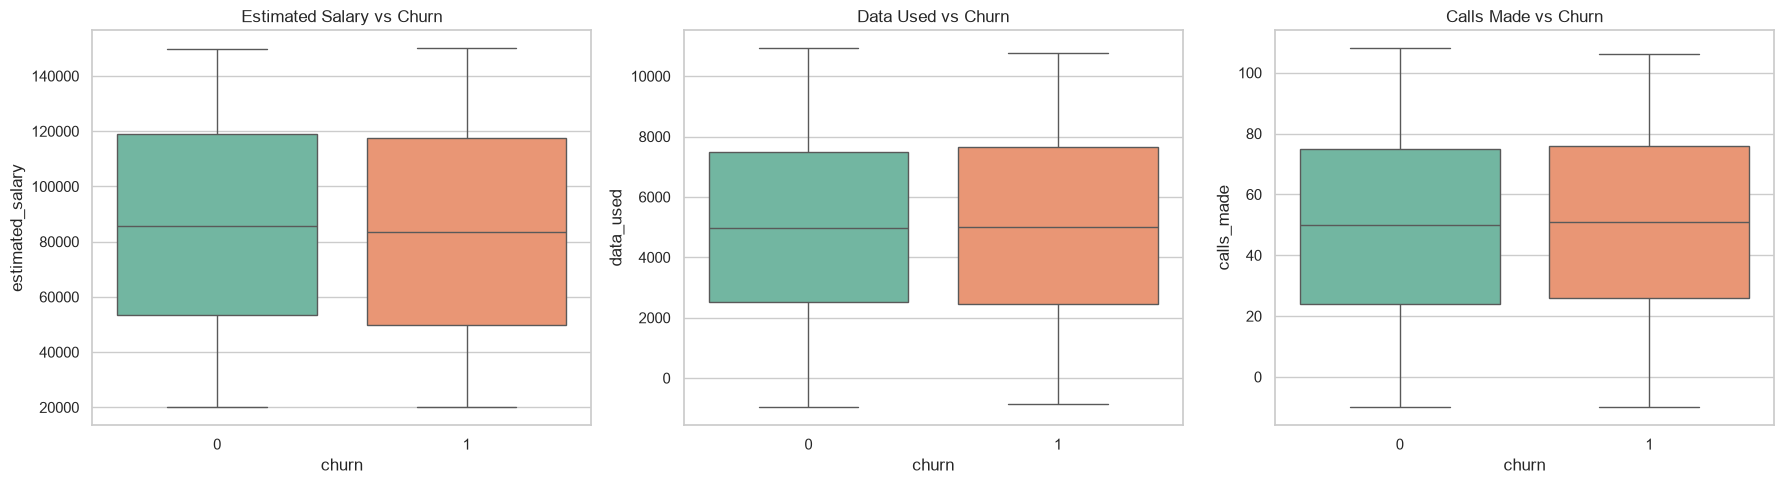

In [13]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Set up a grid for visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# Boxplot: Estimated Salary
sns.boxplot(ax=axes[0], x='churn', y='estimated_salary', data=churn_df, palette="Set2")
axes[0].set_title("Estimated Salary vs Churn")

# Boxplot: Data Used
sns.boxplot(ax=axes[1], x='churn', y='data_used', data=churn_df, palette="Set2")
axes[1].set_title("Data Used vs Churn")

# Boxplot: Calls Made
sns.boxplot(ax=axes[2], x='churn', y='calls_made', data=churn_df, palette="Set2")
axes[2].set_title("Calls Made vs Churn")

plt.tight_layout()
plt.show()

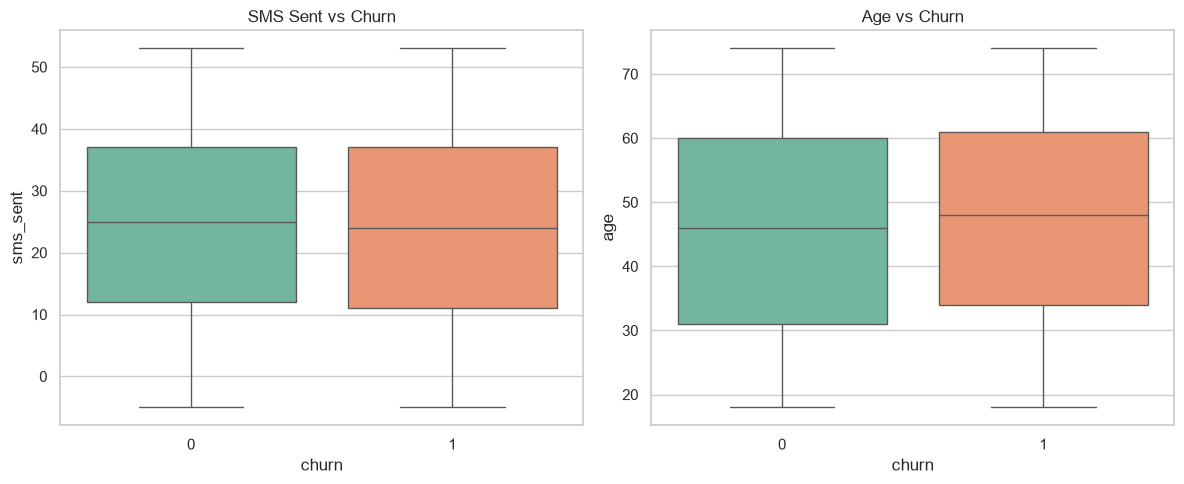

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot: SMS Sent
sns.boxplot(ax=axes[0], x='churn', y='sms_sent', data=churn_df, palette="Set2")
axes[0].set_title("SMS Sent vs Churn")

# Boxplot: Age
sns.boxplot(ax=axes[1], x='churn', y='age', data=churn_df, palette="Set2")
axes[1].set_title("Age vs Churn")

plt.tight_layout()
plt.show()

**Hypothesis 3 Result: True.**

As visualized in the boxplots above, the distributions of the most "important" features are nearly identical for both churners (1) and non-churners (0). The medians, quartiles, and overall ranges perfectly overlap. 

This confirms that **the available variables provide virtually no discriminative signal** to distinguish between a customer who will churn and one who will stay.

---
## Final Conclusion & Business Recommendations

In this project, I tested multiple machine learning algorithms (Logistic Regression, Random Forest) to predict customer churn in the telecom sector. While the initial accuracy looked promising (~80%), a deeper dive revealed a 0% recall rate, meaning the models failed to identify actual churners.

Through rigorous, hypothesis-driven troubleshooting, I proved that the poor performance was **not** caused by algorithm choice, sub-optimal probability thresholds, or class imbalance. Instead, Exploratory Data Analysis (EDA) on the model's top features revealed a fundamental data issue: **the provided features (usage metrics and demographics) do not correlate with churn behavior.**

### Next Steps for the Business:
To build a functional churn prediction model, the data engineering and analytics teams need to source more highly correlated behavioral signals. Recommendations include collecting:
* **Customer Support Interactions:** Number of dropped calls, network complaints, or support tickets logged.
* **Competitor Activity:** Has the customer recently ported a secondary number or inquired about cancellation?
* **Financial Triggers:** Late payments, changes in billing amounts, or rejection of promotional offers.
* **Engagement Metrics:** App uninstalls, decreasing frequency of usage over the last 30 days (trend features rather than static totals).